## Import Liblary

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Data Loading

In [3]:
df = pd.read_csv('/content/cleaned_data.csv')

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,previous_contact,pdays_clean
0,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1,No Previous Contact,NaN
1,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1,No Previous Contact,NaN
2,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1,No Previous Contact,NaN
3,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1,No Previous Contact,NaN
4,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1,No Previous Contact,NaN


In [17]:
segmentation_features = [
    'age',
    'balance',
    'campaign',
    'previous'
]

In [18]:
df_seg = df.copy()

df_seg = df_seg[
    segmentation_features +
    ['deposit']
]

In [19]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    df_seg[
        segmentation_features
    ]
)

In [20]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2,11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(
        scaled_features
    )

    inertia.append(
        kmeans.inertia_
    )

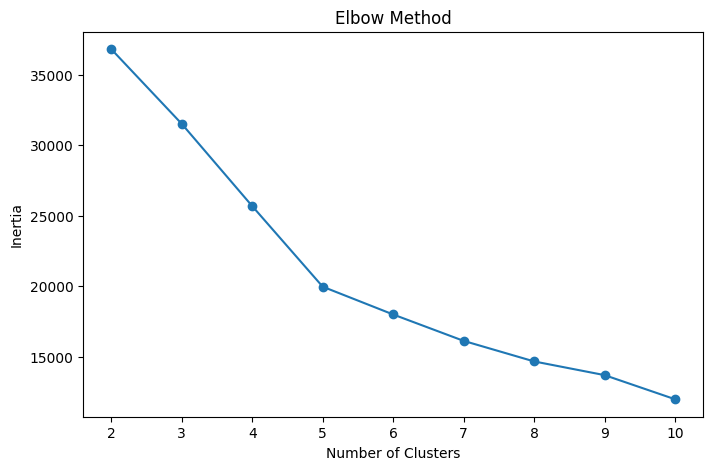

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel(
    'Number of Clusters'
)

plt.ylabel(
    'Inertia'
)

plt.title(
    'Elbow Method'
)

plt.show()

In [22]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(
        scaled_features
    )

    score = silhouette_score(
        scaled_features,
        labels
    )

    print(
        f"K={k}, Silhouette Score={score:.3f}"
    )

K=2, Silhouette Score=0.314
K=3, Silhouette Score=0.312
K=4, Silhouette Score=0.342
K=5, Silhouette Score=0.371
K=6, Silhouette Score=0.378
K=7, Silhouette Score=0.372
K=8, Silhouette Score=0.292
K=9, Silhouette Score=0.294
K=10, Silhouette Score=0.338


In [23]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df_seg['cluster'] = (
    kmeans.fit_predict(
        scaled_features
    )
)

In [24]:
cluster_profile = (
    df_seg
    .groupby('cluster')
    [
        segmentation_features
    ]
    .mean()
    .round(2)
)

cluster_profile

,age,balance,campaign,previous
cluster,,,,
0,40.71,955.77,11.58,0.15
1,43.79,16376.16,2.43,0.75
2,54.69,1445.30,2.10,0.48
3,33.85,1027.21,2.02,0.45
4,41.08,1491.11,2.28,8.40


In [25]:
cluster_conversion = (
    df_seg
    .groupby('cluster')
    ['deposit']
    .mean()
    .round(3)
)

cluster_conversion

,deposit
cluster,
0,0.256
1,0.582
2,0.486
3,0.463
4,0.680


In [26]:
df_seg['cluster'].value_counts()

,count
cluster,
3,6376
2,3477
4,538
0,515
1,256


In [27]:
pd.crosstab(
    df_seg['cluster'],
    df['education'],
    normalize='index'
) * 100

education,primary,secondary,tertiary,unknown
cluster,,,,
0,13.786408,52.038835,29.320388,4.854369
1,10.156250,36.328125,48.828125,4.687500
2,22.318090,44.319816,26.919758,6.442335
3,9.002509,51.819322,35.774780,3.403388
4,9.851301,50.185874,36.431227,3.531599


In [28]:
pd.crosstab(
    df_seg['cluster'],
    df['job'],
    normalize='index'
) * 100

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,13.398058,16.310680,3.689320,2.718447,23.495146,2.912621,4.271845,9.126214,1.553398,19.417476,1.941748,1.165049
1,7.812500,10.937500,2.734375,1.953125,32.421875,8.984375,6.640625,3.906250,2.734375,19.921875,1.171875,0.781250
2,10.037389,15.674432,3.422491,4.314064,20.707506,19.988496,2.962324,5.637043,0.057521,12.884671,3.278689,1.035375
3,12.766625,19.244040,2.713300,1.552698,23.510038,0.156838,3.842535,9.912171,4.909034,17.691343,3.340652,0.360728
4,15.241636,11.152416,1.858736,1.115242,26.579926,6.505576,3.345725,7.063197,5.576208,17.843866,3.159851,0.557621


In [29]:
pd.crosstab(
    df_seg['cluster'],
    df['marital'],
    normalize='index'
) * 100

marital,divorced,married,single
cluster,,,
0,10.291262,64.660194,25.048544
1,8.593750,58.593750,32.812500
2,18.895600,73.281565,7.822836
3,8.077164,47.443538,44.479297
4,8.550186,54.832714,36.617100


In [30]:
pd.crosstab(
    df_seg['cluster'],
    df['housing'],
    normalize='index'
) * 100

housing,0,1
cluster,,
0,50.873786,49.126214
1,65.625000,34.375000
2,64.595916,35.404084
3,45.922208,54.077792
4,51.486989,48.513011


In [31]:
pd.crosstab(
    df_seg['cluster'],
    df['loan'],
    normalize='index'
) * 100

loan,0,1
cluster,,
0,82.718447,17.281553
1,97.265625,2.734375
2,86.712683,13.287317
3,86.684442,13.315558
4,90.148699,9.851301


In [33]:
# Gabungkan cluster ke dataframe utama
df_final = df.copy()

df_final['cluster'] = df_seg['cluster']

In [34]:
cluster_names = {
    0: 'Over-Targeted Working Customers',
    1: 'Premium Wealth Customers',
    2: 'Mature Conservative Customers',
    3: 'Young Emerging Customers',
    4: 'Highly Engaged Loyal Customers'
}

df_final['segment_name'] = (
    df_final['cluster']
    .map(cluster_names)
)

In [36]:
# Save ke CSV
df_final.to_csv(
    'customer_segmentation_5_clusters.csv',
    index=False
)

print("CSV berhasil disimpan!")

CSV berhasil disimpan!
